In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
#Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()
#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

c:\Users\rajay\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


COUNTS OF JOB TITLES

In [2]:
df.pivot_table(index='job_title_short', aggfunc = 'size')

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
dtype: int64

In [3]:
df.groupby('job_title_short').size()

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
dtype: int64

In [4]:
df.pivot_table(index = 'job_title_short', aggfunc = 'median', values = 'salary_year_avg')

,salary_year_avg
job_title_short,
Business Analyst,85000.0
Cloud Engineer,90000.0
Data Analyst,90000.0
Data Engineer,125000.0
Data Scientist,127500.0
Machine Learning Engineer,106415.0
Senior Data Analyst,111175.0
Senior Data Engineer,147500.0
Senior Data Scientist,155500.0


In [ ]:
top_countries = df['job_country'].value_counts().head(10).index
top_countries
df_job_country_salary = df.pivot_table(index='job_country', values='salary_year_avg', aggfunc='median', columns='job_title_short')
df_job_country_salary = df_job_country_salary.loc[top_countries]
job_titles = ['Data Scientist', 'Data Analyst', 'Data Engineer']
df_job_country_salary = df_job_country_salary[job_titles]
df_job_country_salary

job_title_short,Data Scientist,Data Analyst,Data Engineer
job_country,,,
United States,130000.0,90000.0,125000.0
India,114008.0,100500.0,147500.0
United Kingdom,105300.0,87750.0,110000.0
France,88128.0,69175.0,98301.5
Germany,131560.0,103750.0,147500.0
Spain,88128.0,91977.0,133000.0
Singapore,131560.0,99500.0,98301.5
Sudan,130000.0,87500.0,127500.0
Netherlands,157500.0,93852.0,97444.0


Text(0.5, 1.0, 'Median Salary by Job Title and Country')

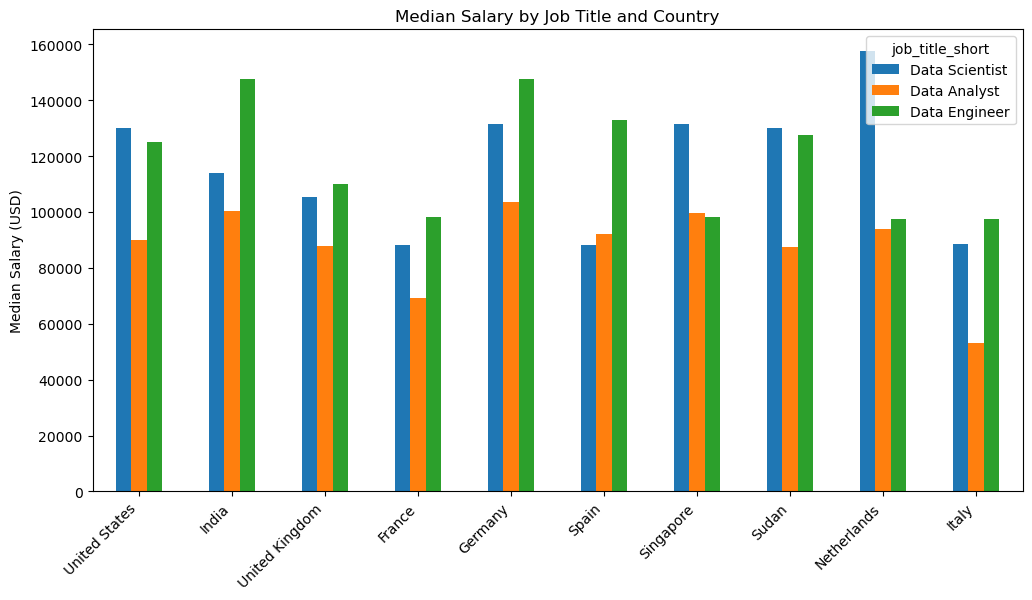

In [18]:
top_countries = df['job_country'].value_counts().head(10).index
top_countries
df_job_country_salary = df.pivot_table(index='job_country', values='salary_year_avg', aggfunc='median', columns='job_title_short')
df_job_country_salary = df_job_country_salary.loc[top_countries]
job_titles = ['Data Scientist', 'Data Analyst', 'Data Engineer']
df_job_country_salary = df_job_country_salary[job_titles]
df_job_country_salary.plot(kind='bar', figsize=(12, 6))
plt.xticks(rotation=45, ha='right')
plt.xlabel('')
plt.ylabel('Median Salary (USD)')
plt.title('Median Salary by Job Title and Country')